In [ ]:
# 1.1 instalare OpenCV

%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1.2 import biblioteca

import cv2 as cv
print('versiune ', cv.__version__)

versiune  4.11.0


In [ ]:
# 1.3 citire imagine color

# image este de tipul. numpy-array uint8
# dimensiunea este de H, W, 3 (H inaltimea, W latimea, 3 numarul de canale rgb)
image1 = cv.imread('butterfly.jpeg')

In [ ]:
# 1.4 citire imagine tonuri de gri

# dimnesiunea este H, W doar
image2 = cv.imread('football.jpg', cv.IMREAD_GRAYSCALE)

In [ ]:
# 1.5 afisare imagini

cv.imshow('windowName', image1)
cv.waitKey(0)    # se asteapta apasarea unei taste
cv.destroyAllWindows()    # se inchide fereastra

cv.imshow('windowName', image2)
cv.waitKey(0)    # se asteapta apasarea unei taste
cv.destroyAllWindows()    # se inchide fereastra

In [10]:
# 1.6 operatii cu o matrice de intensitati 

# img numpy-array 100 ori 100 de tipul uint8 
img = cv.resize(cv.cvtColor(cv.imread('football.jpg'), cv.COLOR_BGR2GRAY), (100, 100))

a) dimensiunea lui x:  (10000, 1)


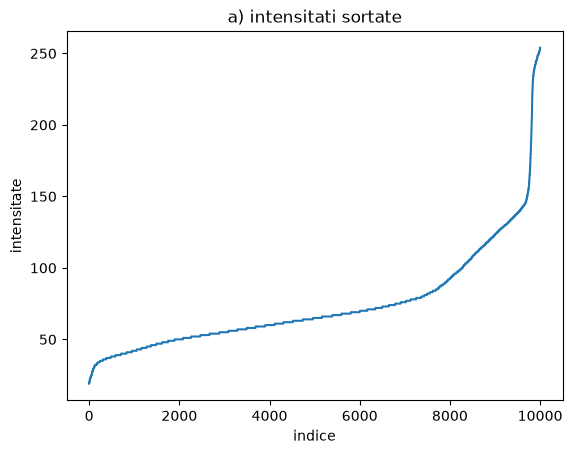

In [12]:
# a) sortati elementele/intensitatile din matricea img punand elementele sortate in vectorul x de dimensiuni 10000 ori 1 

# reshape(-1, 1) este vector de 10000 ori 1
x = np.sort(img.reshape(-1)).reshape(-1, 1)

print('a) dimensiunea lui x: ', x.shape)

plt.figure()
plt.plot(x)
plt.title('a) intensitati sortate')
plt.xlabel('indice')
plt.ylabel('intensitate')
plt.show()

In [13]:
# b) afisati submatricea din img de dimnesiuni 50 ori 50 care corespunde sfertului matricei img din partea dreapta jos

# imaginea mea initiala e de 100 pe 100, deci sfetul din dreapta jos e de la liniile 50 pana la 99 si de la coloanele 50 la 99

submatrice = img[50:100, 50:100]

print('b) submatrice: ', submatrice.shape)
cv.imshow('b) sfertul dreapta jos', submatrice)
cv.waitKey(0)
cv.destroyAllWindows()

b) submatrice:  (50, 50)


In [14]:
# c) pragul de intensitate t cu proprietatea: jumatate din elementele matricei img au o valoare <= t

t = np.median(img)
print('c) pragul t = ', t)

c) pragul t =  65.0


In [15]:
# d) creati si afisati matricea/imaginea B, aceleasi dimensiuni ca img obtinuta din img astfel: fiecare pixel din B are culoarea alba (intensitate 255) daca pixelul corespunzator din img are intensitatea >= t, altfel are culoare neagra (intensitate 0)

B = np.where(img >= t, 255, 0).astype(np.uint8)
cv.imshow('d) imaginea B: ', B)
cv.waitKey(0)
cv.destroyAllWindows()

In [16]:
# e) C - fiecare pixel din C are intensitatea egala cu pixelul corespunzator din img din care se scade intensitatea medie a imaginii img, pixelii astfel obtinuti cu intensitatea <0 vor fi setati ca avand intensitatea = 0 

medie = np.mean(img)
C = img.astype(np.int32) - medie 
C[C < 0] = 0
C = C.astype(np.uint8)

print('e) intensitatea medie = ', medie)
cv.imshow('e) imaginea C', C)
cv.waitKey(0)
cv.destroyAllWindows()

e) intensitatea medie =  74.2772


In [17]:
# f) valoarea minim np.min a intensitatii si afisati pozitiile in care apare np.where in img

minim = np.min(img)
linii, coloane = np.where(img == minim)

print('f) intensitatea minima = ', minim)
print('f) apare de ', len(linii), 'ori, la pozitiile (linie, coloana): ')
print(list(zip(linii, coloane)))

f) intensitatea minima =  19
f) apare de  2 ori, la pozitiile (linie, coloana): 
[(np.int64(76), np.int64(68)), (np.int64(88), np.int64(50))]


In [18]:
# 1.7 imaginea medie a unei colectii de imagini 

def colectie_imagini(dir_path):
    """
    calculeaza imaginea medie color, imaginea medie de intensitate si matricea deviatiilor standard pentru colectia din dir_path
    """

    fisiere = sorted(os.listdir(dir_path))
    extensii = ('.jpg', '.jpeg', '.png', '.bmp')

    imagini_color = []
    imagini_gray = []

    for nume in fisiere:
        if not nume.lower().endswith(extensii):
            continue

        img = cv.imread(os.path.join(dir_path, nume))

        if img is None:
            continue

        imagini_color.append(img.astype(np.float64))
        imagini_gray.append(cv.cvtColor(img, cv.COLOR_BGR2GRAY).astype(np.float64))

    if len(imagini_color) == 0:
        raise ValueError('nu am gasit imagini in ' + dir_path)

    # stive de forma (N, H, W, 3) si (N, H, W)
    stiva_color = np.stack(imagini_color, axis=0)
    stiva_gray = np.stack(imagini_gray, axis=0)

    # a) imaginea medie color --->> media pe axa imaginilor
    img_color = np.mean(stiva_color, axis=0).astype(np.uint8)

    # b) imaginea medie de intensitate
    img_gray = np.mean(stiva_gray, axis=0).astype(np.uint8)

    # c) deviatia standard per pixel
    X = np.std(stiva_gray, axis=0)

    # pentru afisare, normalizez X in intervalul [0, 255]
    X_afisare = cv.normalize(X, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

    # d) afisarea celor trei imagini
    cv.imshow('img_color', img_color)
    cv.imshow('img_gray', img_gray)
    cv.imshow('X (deviatia standard)', X_afisare)
    cv.waitKey(0)
    cv.destroyAllWindows()

    return img_color, img_gray, X

In [19]:
colectie_imagini(os.path.join('colectiiImagini', 'set1'))

(array([[[184, 169, 148],
         [185, 170, 149],
         [184, 169, 148],
         ...,
         [185, 170, 153],
         [185, 169, 153],
         [184, 169, 152]],
 
        [[184, 168, 147],
         [189, 173, 153],
         [188, 173, 152],
         ...,
         [191, 176, 159],
         [188, 173, 156],
         [187, 171, 154]],
 
        [[183, 167, 146],
         [190, 175, 153],
         [189, 173, 152],
         ...,
         [192, 177, 160],
         [188, 172, 155],
         [187, 171, 154]],
 
        ...,
 
        [[142, 132, 118],
         [146, 136, 121],
         [142, 132, 118],
         ...,
         [148, 138, 127],
         [146, 137, 126],
         [145, 135, 124]],
 
        [[142, 132, 118],
         [146, 136, 122],
         [144, 134, 120],
         ...,
         [148, 138, 127],
         [147, 137, 126],
         [144, 135, 124]],
 
        [[143, 134, 120],
         [144, 134, 121],
         [141, 131, 117],
         ...,
         [142, 133, 122],
  

In [20]:
colectie_imagini(os.path.join('colectiiImagini', 'set2'))

(array([[[250, 250, 250],
         [250, 250, 250],
         [250, 250, 250],
         ...,
         [241, 242, 241],
         [242, 244, 243],
         [242, 244, 243]],
 
        [[250, 250, 250],
         [250, 250, 250],
         [250, 250, 250],
         ...,
         [241, 243, 242],
         [242, 244, 243],
         [242, 244, 243]],
 
        [[250, 250, 250],
         [250, 250, 250],
         [250, 250, 250],
         ...,
         [241, 243, 242],
         [242, 244, 243],
         [242, 244, 243]],
 
        ...,
 
        [[248, 249, 249],
         [248, 249, 249],
         [248, 249, 249],
         ...,
         [228, 237, 236],
         [230, 238, 238],
         [230, 239, 238]],
 
        [[248, 249, 249],
         [248, 249, 250],
         [248, 249, 250],
         ...,
         [228, 236, 236],
         [230, 238, 238],
         [230, 238, 238]],
 
        [[248, 249, 250],
         [248, 249, 250],
         [248, 249, 250],
         ...,
         [228, 236, 236],
  

In [21]:
# 1.8 modificarea unei imagini
# imaginea butterfly.jpeg in img
# extrageti 500 de subimagini de dimensiune 20 ori 20 din pozitii aleatorii ale imaginii img
# modificati portiunea din imagine care are coltul stang-sus in pozitia (250, 250) cu cea mai apropiata subimagine (din cele 500) conform distantei L2

def modif_imagine(cale_imagine='butterfly.jpeg', nr_patch=500, dim=20, pozitie=(250, 250), cale_salvare='butterly_modificat.jpg'):
    img = cv.imread(cale_imagine)
    H, W = img.shape[:2]

    # portiunea care trebuie inlocuita
    y0, x0 = pozitie
    tinta = img[y0:y0 + dim, x0:x0 + dim].astype(np.float64)

    # extrag cele 500 de subimagini din pozitii aleatorii
    patchuri = []
    for _ in range(nr_patch):
        y = np.random.randint(0, H - dim + 1)
        x = np.random.randint(0, W - dim + 1)

        patchuri.append(img[y:y + dim, x:x + dim])

    # cea mai apropiata subimagine conform distantei L2
    distanta_minima = np.inf 
    cel_mai_apropiat = None 

    for p in patchuri:
        d = np.sqrt(np.sum((p.astype(np.float64) - tinta) ** 2))

        if d < distanta_minima:
            distanta_minima = d
            cel_mai_apropiat = p 

    print('distanta L2 minima = ', distanta_minima)

    # inlocuiesc portiunea si salvez
    img_modificat = img.copy()
    img_modificat[y0:y0 + dim, x0:x0 + dim] = cel_mai_apropiat
    cv.imwrite(cale_salvare, img_modificat)

    cv.imshow('imagine originala', img)
    cv.imshow('imagine modificata', img_modificat)

    cv.waitKey(0)
    cv.destroyAllWindows()

    return img_modificat

In [22]:
modif_imagine('butterfly.jpeg')

distanta L2 minima =  1739.673820001899


array([[[ 0, 29,  6],
        [ 1, 30,  7],
        [ 1, 30,  7],
        ...,
        [ 1, 62, 42],
        [ 0, 62, 42],
        [ 0, 62, 42]],

       [[ 1, 30,  7],
        [ 1, 30,  7],
        [ 1, 30,  7],
        ...,
        [ 1, 62, 42],
        [ 0, 62, 42],
        [ 0, 62, 42]],

       [[ 1, 30,  7],
        [ 1, 30,  7],
        [ 2, 31,  8],
        ...,
        [ 1, 62, 42],
        [ 0, 62, 42],
        [ 0, 62, 42]],

       ...,

       [[ 1, 97, 86],
        [ 1, 97, 86],
        [ 1, 97, 86],
        ...,
        [ 2, 62, 38],
        [ 0, 62, 40],
        [ 0, 62, 40]],

       [[ 1, 97, 86],
        [ 1, 97, 86],
        [ 1, 97, 86],
        ...,
        [ 2, 62, 38],
        [ 0, 62, 40],
        [ 0, 62, 40]],

       [[ 2, 98, 87],
        [ 2, 98, 87],
        [ 2, 98, 87],
        ...,
        [ 2, 62, 38],
        [ 0, 62, 40],
        [ 0, 62, 40]]], shape=(670, 626, 3), dtype=uint8)